# Paper Figures — Ablations & Supplementary

Supporting figures: k-mer scale, linear probe, pooling robustness, canonical k-mers, PCA, AUROC/MCC concordance, truncation, efficiency.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy import stats

ROOT    = Path('/home/oem/genome-cgr-embedding')
RESULTS = ROOT / 'results'
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

mpl.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':         8,
    'axes.titlesize':    9,
    'axes.labelsize':    8,
    'xtick.labelsize':   7,
    'ytick.labelsize':   7,
    'legend.fontsize':   7,
    'figure.dpi':       150,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'axes.grid.axis':   'y',
    'grid.alpha':       0.35,
    'grid.linewidth':   0.5,
})

FM_COLORS = {'NTv3':'#2563EB','HyenaDNA':'#D97706','DNABERT-2':'#059669','Caduceus':'#7C3AED'}
KMER_COLOR = '#6B7280'
MODEL_LABELS = {
    'NTv3_650M_pre':                                  'NTv3 (650M)',
    'hyenadna-medium-160k-seqlen-hf':                 'HyenaDNA',
    'DNABERT-2-117M':                                 'DNABERT-2',
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16': 'Caduceus',
}
MODEL_COLOR_KEY = {
    'NTv3_650M_pre':                                  'NTv3',
    'hyenadna-medium-160k-seqlen-hf':                 'HyenaDNA',
    'DNABERT-2-117M':                                 'DNABERT-2',
    'caduceus-ph_seqlen-131k_d_model-256_n_layer-16': 'Caduceus',
}
GROUP_PALETTE = {
    'EMP':'#EF4444','deep4mc':'#F97316','enhancers':'#EAB308',
    'genomic_benchmark':'#22C55E','iDHS-EL':'#06B6D4','iDNA_ABF':'#6366F1',
    'iPro-WAEL':'#EC4899','mouse':'#14B8A6','prom':'#A855F7',
    'splice':'#F43F5E','tf':'#0EA5E9','virus':'#84CC16',
}

def task_group(name): return name.split('/')[0]
def savefig(name):
    p = FIG_DIR / name; plt.savefig(p, bbox_inches='tight'); print(f'Saved -> {p}')

print('Setup complete.')


Setup complete.


## Load data

In [2]:
rf      = pd.read_csv(RESULTS / 'classification/records_rf.csv')
lp      = pd.read_csv(RESULTS / 'classification/records_linear_probe.csv')
pca     = pd.read_csv(RESULTS / 'classification/records_pca.csv')
ck      = pd.read_csv(RESULTS / 'classification/records_canonical_kmer.csv')
dec     = pd.read_csv(RESULTS / 'decomposition/records_decomposition.csv')
auc_con = pd.read_csv(RESULTS / 'analysis/auroc_consistency.csv')
eff_gpu = pd.read_csv(RESULTS / 'efficiency/efficiency_gpu_parallel.csv')
trunc   = pd.read_csv(RESULTS / 'classification/truncation_analysis.csv')

rf['group']          = rf['dataset'].apply(task_group)
rf['best_kmer_MCC']  = rf[['kmer_k4_MCC','kmer_k5_MCC','kmer_k6_MCC']].max(axis=1)
rf['best_kmer_AUROC']= rf[['kmer_k4_AUROC','kmer_k5_AUROC','kmer_k6_AUROC']].max(axis=1)

print('All data loaded.')


All data loaded.


---
## Ablation 1 — k-mer Scale: k=4,5,6 and Multiscale Concatenation

Violin + strip plots of MCC across 57 datasets.
Shows the effect of k-mer size and whether multiscale concatenation helps.

Saved -> /home/oem/genome-cgr-embedding/figures/abl1_kmer_scale.pdf


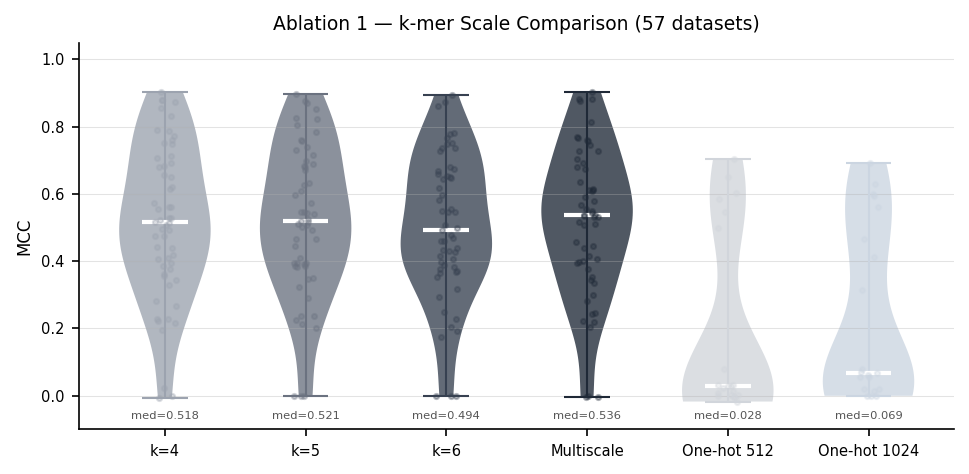

In [3]:
VARIANTS = [
    ('k=4',         'kmer_k4_MCC',       '#9CA3AF'),
    ('k=5',         'kmer_k5_MCC',       '#6B7280'),
    ('k=6',         'kmer_k6_MCC',       '#374151'),
    ('Multiscale',  'kmer_multi_k4_5_6_MCC', '#1F2937'),
    ('One-hot 512', 'onehot_512bp_MCC',  '#D1D5DB'),
    ('One-hot 1024','onehot_1024bp_MCC', '#CBD5E1'),
]

fig, ax = plt.subplots(figsize=(6.5, 3.2))

for i, (label, col, color) in enumerate(VARIANTS):
    if col not in rf.columns: continue
    vals = rf[col].dropna().values
    parts = ax.violinplot(vals, positions=[i], showmedians=True, widths=0.65)
    for pc in parts['bodies']: pc.set_facecolor(color); pc.set_alpha(0.78)
    parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
    for p in ('cbars','cmins','cmaxes'): parts[p].set_color(color); parts[p].set_linewidth(1)
    jit = np.random.default_rng(42+i).uniform(-0.08,0.08, len(vals))
    ax.scatter(np.full(len(vals),i)+jit, vals, color=color, alpha=0.35, s=6, zorder=3)
    ax.text(i, -0.07, f'med={np.median(vals):.3f}', ha='center', fontsize=5.5, color='#555')

ax.set_xticks(range(len(VARIANTS)))
ax.set_xticklabels([v[0] for v in VARIANTS])
ax.set_ylabel('MCC')
ax.set_ylim(-0.1, 1.05)
ax.set_title('Ablation 1 — k-mer Scale Comparison (57 datasets)', fontsize=9)

plt.tight_layout()
savefig('abl1_kmer_scale.pdf')
plt.show()


---
## Ablation 2 — Linear Probe vs. Random Forest

Paired scatter: RF MCC vs. linear probe MCC for FM models and k-mer baselines.
Points above diagonal: RF > linear probe (architecture advantage).
Points below diagonal: linear probe better (suggests redundant features).

Saved -> /home/oem/genome-cgr-embedding/figures/abl2_linear_probe.pdf


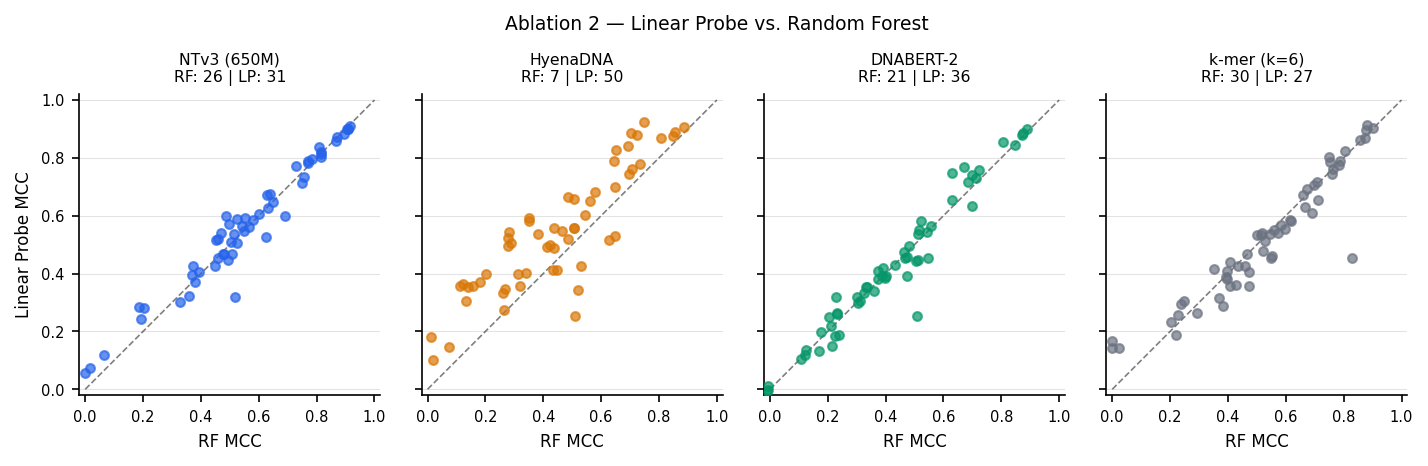

In [4]:
merged_lp = rf[['dataset','best_kmer_MCC',
                'fm_NTv3_650M_pre_MCC',
                'fm_hyenadna-medium-160k-seqlen-hf_MCC',
                'fm_DNABERT-2-117M_MCC']].merge(
    lp[['dataset','lp_kmer_k6_MCC',
        'lp_fm_NTv3_650M_pre_MCC__pool_max',
        'lp_fm_hyenadna-medium-160k-seqlen-hf_MCC',
        'lp_fm_DNABERT-2-117M_MCC']],
    on='dataset')

comps = [
    ('fm_NTv3_650M_pre_MCC',                  'lp_fm_NTv3_650M_pre_MCC__pool_max',       'NTv3 (650M)',  FM_COLORS['NTv3']),
    ('fm_hyenadna-medium-160k-seqlen-hf_MCC', 'lp_fm_hyenadna-medium-160k-seqlen-hf_MCC','HyenaDNA',     FM_COLORS['HyenaDNA']),
    ('fm_DNABERT-2-117M_MCC',                 'lp_fm_DNABERT-2-117M_MCC',                'DNABERT-2',    FM_COLORS['DNABERT-2']),
    ('best_kmer_MCC',                         'lp_kmer_k6_MCC',                          'k-mer (k=6)',  KMER_COLOR),
]

fig, axes = plt.subplots(1, 4, figsize=(9.6, 2.8), sharex=True, sharey=True)
fig.suptitle('Ablation 2 — Linear Probe vs. Random Forest', fontsize=9, y=1.02)

for ax, (rc, lc, label, color) in zip(axes, comps):
    x = merged_lp[rc].values
    y = merged_lp[lc].values
    valid = ~(np.isnan(x) | np.isnan(y))
    ax.scatter(x[valid], y[valid], color=color, alpha=0.7, s=18, zorder=3)
    ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
    rf_wins = int((x[valid] > y[valid]).sum())
    lp_wins = int((y[valid] > x[valid]).sum())
    title = label + '\nRF: ' + str(rf_wins) + ' | LP: ' + str(lp_wins)
    ax.set_title(title, fontsize=7.5)
    ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02); ax.set_aspect('equal')
    ax.set_xlabel('RF MCC')

axes[0].set_ylabel('Linear Probe MCC')
plt.tight_layout()
savefig('abl2_linear_probe.pdf')
plt.show()


---
## Ablation 3 — Decomposition Robustness: Pooling Strategy (NTv3)

Ridge R² for NTv3 under mean/max/CLS pooling across k=4,5,6.
Shows that the k-mer explainability of FM embeddings is consistent across pooling methods.

Saved -> /home/oem/genome-cgr-embedding/figures/abl3_pooling_robustness.pdf


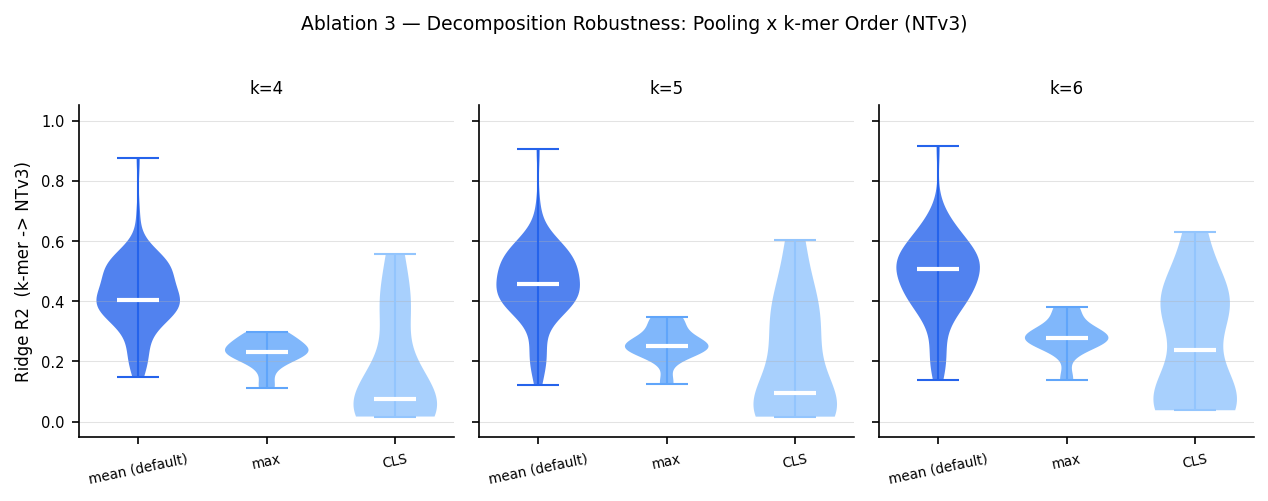

In [5]:
model = 'NTv3_650M_pre'
configs = [
    ('mean (default)', 'ridge_k{k}_' + model + '_R2',                         '#2563EB'),
    ('max',            'ridge_k{k}_' + model + '_R2__pool_max__map_ridge',     '#60A5FA'),
    ('CLS',            'ridge_k{k}_' + model + '_R2__pool_cls__map_ridge',     '#93C5FD'),
]
ks = [4, 5, 6]

fig, axes = plt.subplots(1, 3, figsize=(8.5, 3.2), sharey=True)
fig.suptitle('Ablation 3 — Decomposition Robustness: Pooling x k-mer Order (NTv3)', fontsize=9, y=1.02)

for ax, k in zip(axes, ks):
    for i, (pool_label, col_tmpl, color) in enumerate(configs):
        col = col_tmpl.format(k=k)
        if col not in dec.columns: continue
        vals = dec[col].dropna().values
        parts = ax.violinplot(vals, positions=[i], showmedians=True, widths=0.65)
        for pc in parts['bodies']: pc.set_facecolor(color); pc.set_alpha(0.8)
        parts['cmedians'].set_color('white'); parts['cmedians'].set_linewidth(2)
        for p in ('cbars','cmins','cmaxes'): parts[p].set_color(color); parts[p].set_linewidth(1)
    ax.set_xticks(range(len(configs)))
    ax.set_xticklabels([c[0] for c in configs], fontsize=6.5, rotation=12)
    ax.set_title('k=' + str(k), fontsize=8)
    ax.set_ylim(-0.05,1.05)

axes[0].set_ylabel('Ridge R2  (k-mer -> NTv3)')
plt.tight_layout()
savefig('abl3_pooling_robustness.pdf')
plt.show()


---
## Ablation 4 — Canonical vs. Standard k-mers

Paired scatter: canonical (reverse-complement normalised) vs. standard k-mer MCC.
Checks whether strand symmetry in k-mer counting matters for classification.

Saved -> /home/oem/genome-cgr-embedding/figures/abl4_canonical_kmer.pdf


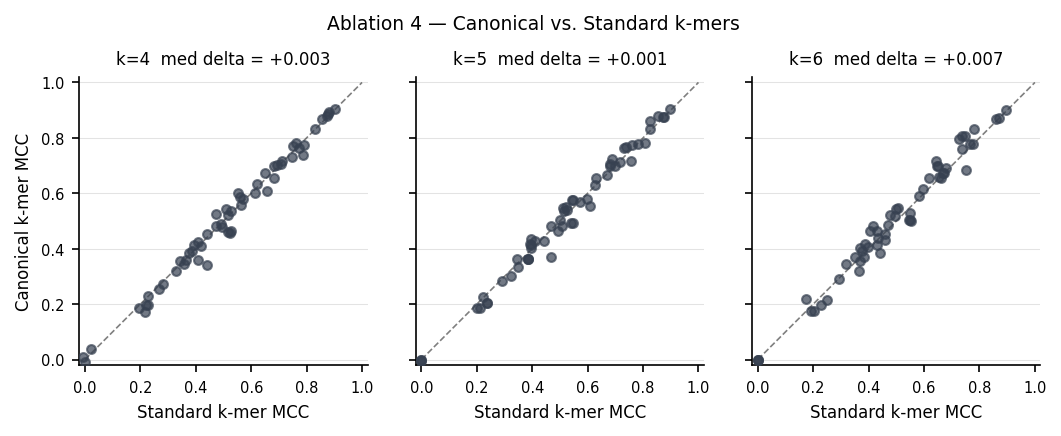

In [6]:
merged_ck = rf[['dataset','kmer_k4_MCC','kmer_k5_MCC','kmer_k6_MCC']].merge(
    ck[['dataset','ckmer_k4_MCC','ckmer_k5_MCC','ckmer_k6_MCC']], on='dataset')

fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), sharex=True, sharey=True)
fig.suptitle('Ablation 4 — Canonical vs. Standard k-mers', fontsize=9, y=1.02)

for ax, k in zip(axes, [4,5,6]):
    x = merged_ck[f'kmer_k{k}_MCC'].values
    y = merged_ck[f'ckmer_k{k}_MCC'].values
    ax.scatter(x, y, color='#374151', alpha=0.7, s=18, zorder=3)
    ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
    diff = float(np.median(y - x))
    ax.set_title('k=' + str(k) + '  med delta = ' + f'{diff:+.3f}', fontsize=8)
    ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02); ax.set_aspect('equal')
    ax.set_xlabel('Standard k-mer MCC')

axes[0].set_ylabel('Canonical k-mer MCC')
plt.tight_layout()
savefig('abl4_canonical_kmer.pdf')
plt.show()


---
## Ablation 5 — PCA Dimensionality Reduction

Full-dim vs. PCA-compressed features for FM and k-mer methods.
Tests whether k=6 (4096 dims) benefits from dimensionality reduction.

Saved -> /home/oem/genome-cgr-embedding/figures/abl5_pca.pdf


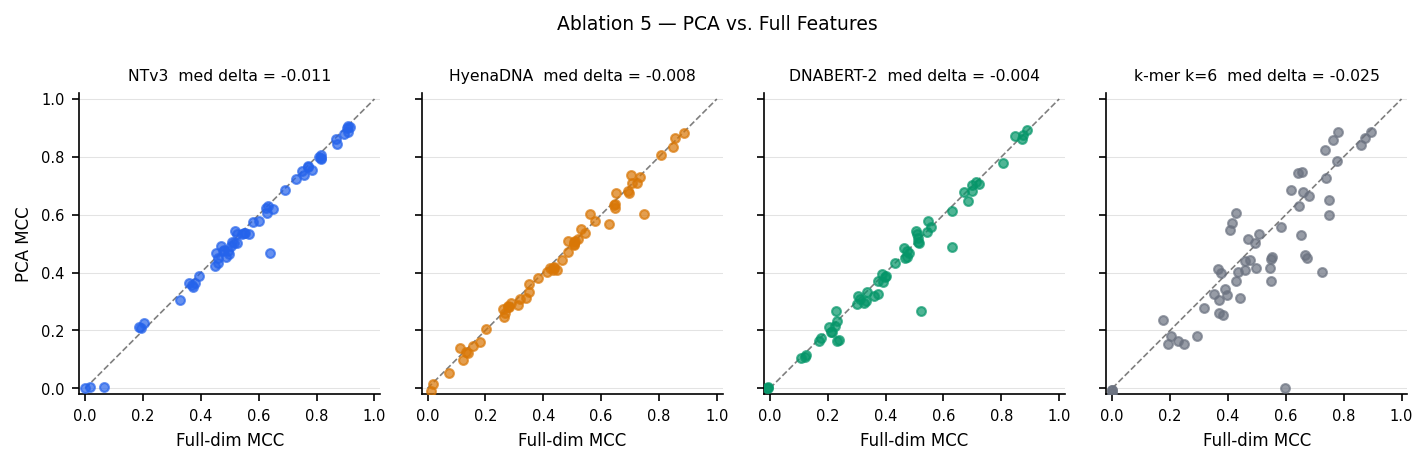

In [7]:
merged_pca = rf[['dataset',
                 'fm_NTv3_650M_pre_MCC',
                 'fm_hyenadna-medium-160k-seqlen-hf_MCC',
                 'fm_DNABERT-2-117M_MCC',
                 'kmer_k4_MCC','kmer_k5_MCC','kmer_k6_MCC']].merge(
    pca[['dataset',
         'pca_fm_NTv3_650M_pre_MCC',
         'pca_fm_hyenadna-medium-160k-seqlen-hf_MCC',
         'pca_fm_DNABERT-2-117M_MCC',
         'pca_kmer_k4_MCC','pca_kmer_k5_MCC','pca_kmer_k6_MCC']],
    on='dataset')

pairs = [
    ('fm_NTv3_650M_pre_MCC',                  'pca_fm_NTv3_650M_pre_MCC',                  'NTv3',     FM_COLORS['NTv3']),
    ('fm_hyenadna-medium-160k-seqlen-hf_MCC', 'pca_fm_hyenadna-medium-160k-seqlen-hf_MCC', 'HyenaDNA', FM_COLORS['HyenaDNA']),
    ('fm_DNABERT-2-117M_MCC',                 'pca_fm_DNABERT-2-117M_MCC',                 'DNABERT-2',FM_COLORS['DNABERT-2']),
    ('kmer_k6_MCC',                           'pca_kmer_k6_MCC',                           'k-mer k=6',KMER_COLOR),
]

fig, axes = plt.subplots(1, 4, figsize=(9.6, 2.8), sharex=True, sharey=True)
fig.suptitle('Ablation 5 — PCA vs. Full Features', fontsize=9, y=1.02)

for ax, (fc, pc_col, label, color) in zip(axes, pairs):
    x = merged_pca[fc].values
    y = merged_pca[pc_col].values
    valid = ~(np.isnan(x) | np.isnan(y))
    ax.scatter(x[valid], y[valid], color=color, alpha=0.7, s=18, zorder=3)
    ax.plot([0,1],[0,1],'k--',lw=0.8,alpha=0.5)
    diff = float(np.median((y-x)[valid]))
    ax.set_title(label + '  med delta = ' + f'{diff:+.3f}', fontsize=7.5)
    ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02); ax.set_aspect('equal')
    ax.set_xlabel('Full-dim MCC')

axes[0].set_ylabel('PCA MCC')
plt.tight_layout()
savefig('abl5_pca.pdf')
plt.show()


---
## Ablation 6 — MCC vs. AUROC Ranking Concordance

Scatter of ΔMCC vs ΔAUROC (FM − best k-mer) across 57 datasets.
Discordant points (upper-left or lower-right) expose tasks where metrics disagree.

Saved -> /home/oem/genome-cgr-embedding/figures/abl6_concordance.pdf


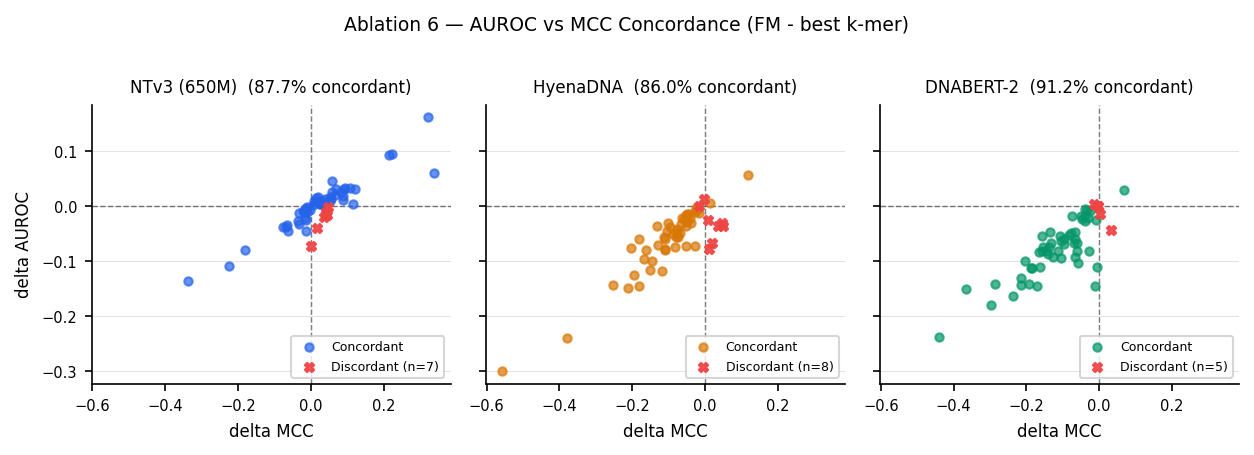

In [8]:
MODELS = [
    ('NTv3_650M_pre',              'NTv3 (650M)',  FM_COLORS['NTv3']),
    ('hyenadna-medium-160k-seqlen-hf','HyenaDNA',  FM_COLORS['HyenaDNA']),
    ('DNABERT-2-117M',             'DNABERT-2',    FM_COLORS['DNABERT-2']),
]

fig, axes = plt.subplots(1, 3, figsize=(8.4, 2.9), sharex=True, sharey=True)
fig.suptitle('Ablation 6 — AUROC vs MCC Concordance (FM - best k-mer)', fontsize=9, y=1.02)

for ax, (mkey, label, color) in zip(axes, MODELS):
    dm  = (rf[f'fm_{mkey}_MCC']   - rf['best_kmer_MCC']).values
    da  = (rf[f'fm_{mkey}_AUROC'] - rf['best_kmer_AUROC']).values
    conc = ((dm > 0) & (da > 0)) | ((dm < 0) & (da < 0))

    ax.scatter(dm[ conc], da[ conc], color=color,    alpha=0.7, s=16, zorder=3, label='Concordant')
    ax.scatter(dm[~conc], da[~conc], color='#EF4444', alpha=0.9, s=20,
               marker='X', zorder=4, label='Discordant (n=' + str((~conc).sum()) + ')')
    ax.axvline(0, color='black', lw=0.7, ls='--', alpha=0.5)
    ax.axhline(0, color='black', lw=0.7, ls='--', alpha=0.5)
    pct = conc.mean()*100
    ax.set_title(label + '  (' + f'{pct:.1f}' + '% concordant)', fontsize=8)
    ax.set_xlabel('delta MCC')
    ax.legend(fontsize=6, loc='lower right')

axes[0].set_ylabel('delta AUROC')
plt.tight_layout()
savefig('abl6_concordance.pdf')
plt.show()


---
## Ablation 7 — Computational Efficiency: GPU FLOPs (NTv3)

NTv3 GPU FLOPs per sequence as a function of sequence length.
Illustrates the quadratic cost of transformer attention vs. linear k-mer counting.

Saved -> /home/oem/genome-cgr-embedding/figures/abl7_efficiency.pdf


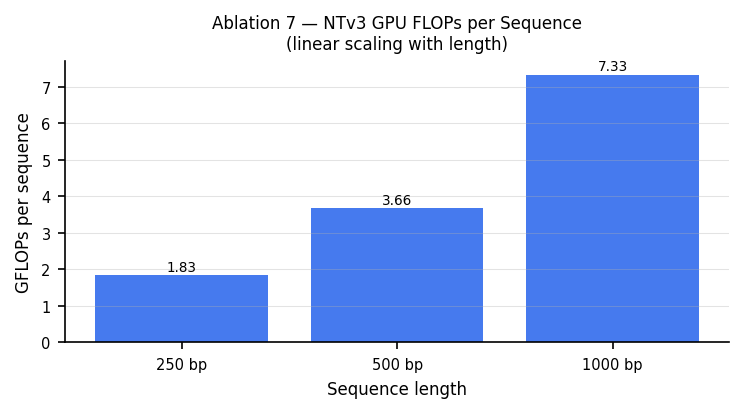

In [9]:
eff_ntv3 = eff_gpu[eff_gpu['method'] == 'fm_NTv3_650M_pre'].copy()

fig, ax = plt.subplots(figsize=(5.0, 2.8))
seq_labels = [str(int(s)) + ' bp' for s in eff_ntv3['seq_len']]
bars = ax.bar(seq_labels, eff_ntv3['GFLOPS_per_seq'],
              color=FM_COLORS['NTv3'], alpha=0.85)

for bar, val in zip(bars, eff_ntv3['GFLOPS_per_seq']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{val:.2f}', ha='center', va='bottom', fontsize=6.5)

ax.set_ylabel('GFLOPs per sequence')
ax.set_xlabel('Sequence length')
ax.set_title('Ablation 7 — NTv3 GPU FLOPs per Sequence\n(linear scaling with length)', fontsize=8)
plt.tight_layout()
savefig('abl7_efficiency.pdf')
plt.show()


---
## Ablation 8 — FM Tokenization Truncation Analysis

Per-model distribution of truncation rates across 57 datasets.
Verifies that FM results are not confounded by sequence truncation.

In [10]:
print(trunc.columns.tolist())
print(trunc.head(3))


['model', 'dataset', 'split', 'max_length', 'n_sequences', 'n_truncated', 'truncation_rate', 'mean_tokens', 'max_tokens', 'fraction_retained_mean']
                       model            dataset  split  max_length  \
0  InstaDeepAI/NTv3_650M_pre       EMP/Yeast_H3  train       32768   
1  InstaDeepAI/NTv3_650M_pre       EMP/Yeast_H3   test       32768   
2  InstaDeepAI/NTv3_650M_pre  EMP/Yeast_H3K14ac  train       32768   

   n_sequences  n_truncated  truncation_rate  mean_tokens  max_tokens  \
0        10475            0              0.0   499.961814         500   
1         4490            0              0.0   500.000000         500   
2        23133            0              0.0   499.980504         500   

   fraction_retained_mean  
0                     1.0  
1                     1.0  
2                     1.0  


Saved -> /home/oem/genome-cgr-embedding/figures/abl8_truncation.pdf


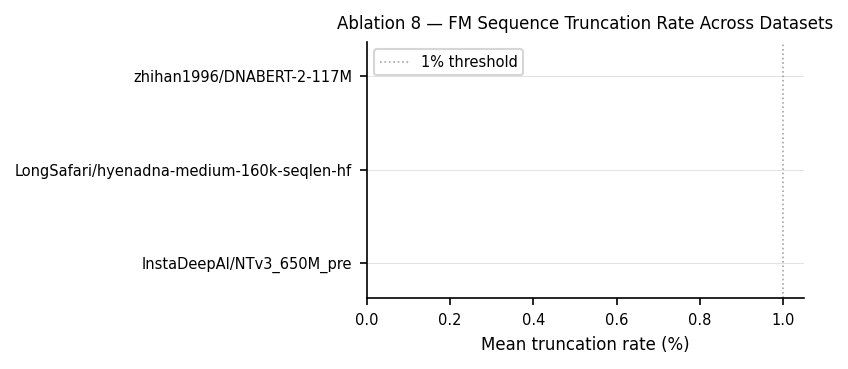

In [11]:
trunc_grp = (trunc.groupby('model')['truncation_rate']
             .agg(mean='mean', median='median', max='max')
             .reset_index())

colors_t = [FM_COLORS.get(MODEL_COLOR_KEY.get(m,''), '#888') for m in trunc_grp['model']]
mlabels  = [MODEL_LABELS.get(m, m) for m in trunc_grp['model']]

fig, ax = plt.subplots(figsize=(5.5, 2.5))
ax.barh(mlabels, trunc_grp['mean'] * 100, color=colors_t, alpha=0.85, height=0.5)
ax.axvline(1, color='gray', ls=':', lw=0.8, alpha=0.7, label='1% threshold')
ax.set_xlabel('Mean truncation rate (%)')
ax.set_title('Ablation 8 — FM Sequence Truncation Rate Across Datasets', fontsize=8)
ax.legend(fontsize=7)
plt.tight_layout()
savefig('abl8_truncation.pdf')
plt.show()
